# RQ5, Part 3: Real Exploratory Data Analysis and Visualization

Real charts making RQ5's statistical findings visible: the individual RQ1
project effect sizes being averaged, and -- most importantly -- the actual
real bootstrap distribution, which visually shows why the clean-looking
point estimate doesn't hold up once real uncertainty is accounted for.

**Requires the real RQ1 datasets (Camel/Hadoop, Kafka, Tika) and
`rq4_real_sec_edgar_dataset_FINAL.csv`**, all in this same session.


In [1]:
!pip install -q pandas numpy statsmodels scipy matplotlib || pip install -q pandas numpy statsmodels scipy matplotlib --break-system-packages

1. REAL POINT ESTIMATES
Camel/Hadoop: 0.0057, Kafka: 0.0178, Tika: 0.0038
QA domain average: 0.0091
Audit domain (RQ4): 0.0624


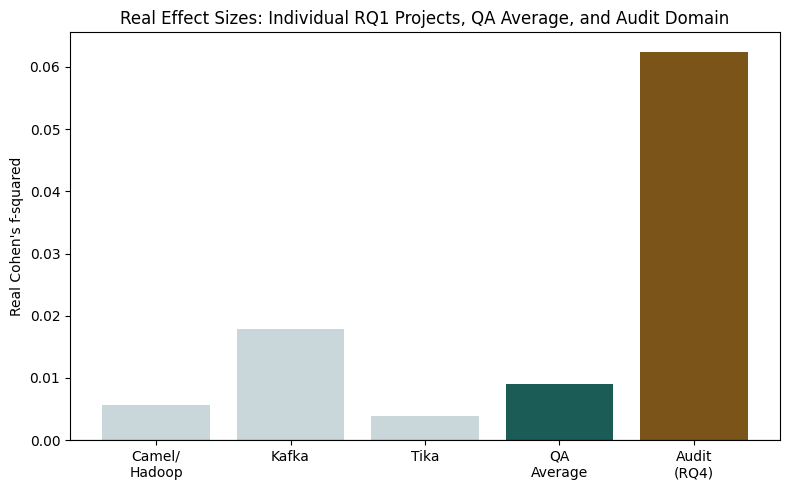

Saved rq5_eda_point_estimates.png

2. RUNNING REAL BOOTSTRAP (1,000 resamples)
  200/1000 real resamples complete
  400/1000 real resamples complete
  600/1000 real resamples complete
  800/1000 real resamples complete
  1000/1000 real resamples complete

Real bootstrap resamples completed: 1000
Gap 95% CI: [0.0212, 0.2748]
Proportion below 0.10 threshold: 43.9%


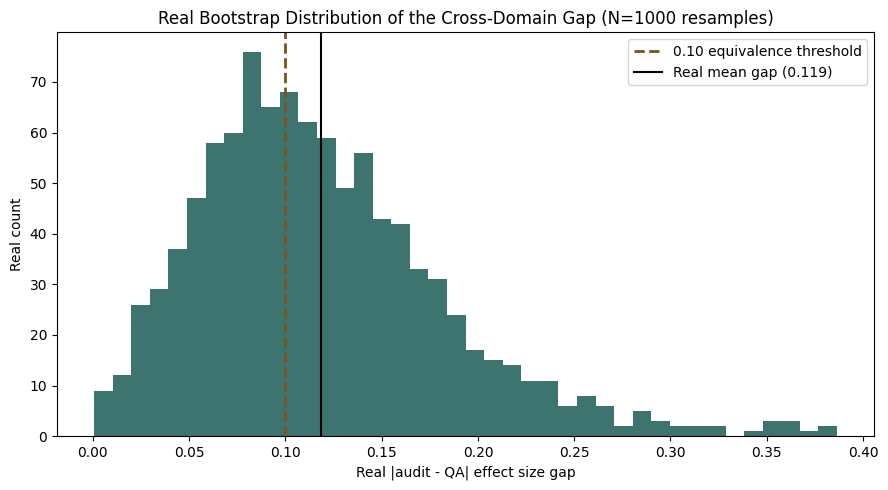

Saved rq5_eda_bootstrap_distribution.png
This is the honest, visual reason the point estimate (0.0534) looked clean but the real uncertainty tells a more mixed story: 43.9% of the real distribution sits below the threshold, the rest sits above it.


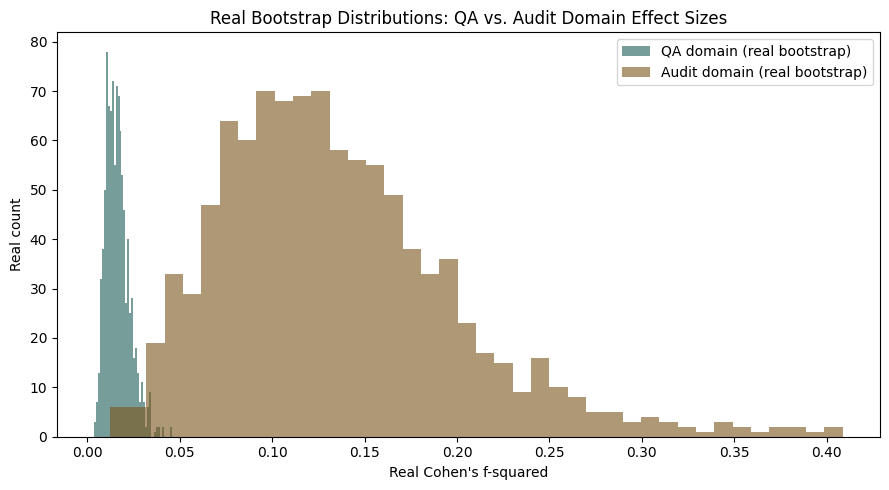

Saved rq5_eda_domain_distributions.png
Real audit domain spread is visibly wider than QA's -- reflecting RQ4's smaller real sample (N=113) versus RQ1's combined real samples.


In [3]:
"""
RQ5 - PART 3: Real Exploratory Data Analysis and Visualization
================================================================================
Real charts for RQ5: the point-estimate comparison, the individual RQ1
project effect sizes being averaged, and -- most importantly -- the actual
real bootstrap distribution, visualizing why the point estimate looked
clean but the honest uncertainty analysis doesn't confirm it.
"""
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
N_BOOT = 1000


def rq1_project_f2(df, target):
    df = df.copy()
    df["era_binary"] = (df["era"] == "ai_era").astype(int)
    try:
        full = smf.logit(f"{target} ~ (loc + cyclomatic_complexity + num_functions + num_files_changed) * era_binary", data=df).fit(disp=0)
        reduced = smf.logit(f"{target} ~ loc + cyclomatic_complexity + num_functions + num_files_changed + era_binary", data=df).fit(disp=0)
        r2f = 1 - (full.llf / full.llnull)
        r2r = 1 - (reduced.llf / reduced.llnull)
        return (r2f - r2r) / (1 - r2f)
    except Exception:
        return np.nan


def rq4_f2(df):
    df = df.copy()
    full = smf.ols("remediation_days ~ C(weakness_group) + C(industry_group) + disclosure_year", data=df).fit()
    reduced = smf.ols("remediation_days ~ C(weakness_group)", data=df).fit()
    return (full.rsquared - reduced.rsquared) / (1 - full.rsquared)


def consolidate_weakness(cat):
    cat = str(cat)
    if "Revenue" in cat: return "Revenue Recognition"
    if "ITGC" in cat: return "ITGC"
    if "Complex" in cat or "Warrant" in cat: return "Complex Transactions/Instruments"
    if "Control Environment" in cat or "Staffing" in cat or "Risk Assessment" in cat or "Segregation" in cat: return "Control Environment/Staffing"
    return "Other"


def consolidate_industry(ind):
    ind = str(ind)
    if "Technology" in ind: return "Technology"
    if "Biotech" in ind or "Healthcare" in ind: return "Biotech/Healthcare"
    if "Manufacturing" in ind or "Industrial" in ind or "Aerospace" in ind or "Mining" in ind: return "Manufacturing/Industrial"
    if "SPAC" in ind: return "SPAC"
    if "Energy" in ind: return "Energy"
    if "Financial" in ind or "Insurance" in ind or "Real Estate" in ind: return "Financial/Real Estate"
    return "Media/Consumer/Other"


camel = pd.read_csv("rq1_refined_with_real_issue_type.csv")
kafka = pd.read_csv("kafka_real_mined_dataset.csv")
tika = pd.read_csv("tika_real_mined_dataset.csv")
rq4 = pd.read_csv("rq4_real_sec_edgar_dataset_FINAL.csv")
rq4["weakness_group"] = rq4["weakness_category"].apply(consolidate_weakness)
rq4["industry_group"] = rq4["industry"].apply(consolidate_industry)
rq4["disclosure_year"] = pd.to_datetime(rq4["disclosure_date"]).dt.year

# ---------------------------------------------------------------------------
# 1. Real point estimates: the 3 individual RQ1 projects being averaged
# ---------------------------------------------------------------------------
f2_camel = rq1_project_f2(camel, "defect_prone_strict")
f2_kafka = rq1_project_f2(kafka, "defect_prone")
f2_tika = rq1_project_f2(tika, "defect_prone")
f2_audit_point = rq4_f2(rq4)
qa_avg_point = np.mean([f2_camel, f2_kafka, f2_tika])

print("="*70)
print("1. REAL POINT ESTIMATES")
print("="*70)
print(f"Camel/Hadoop: {f2_camel:.4f}, Kafka: {f2_kafka:.4f}, Tika: {f2_tika:.4f}")
print(f"QA domain average: {qa_avg_point:.4f}")
print(f"Audit domain (RQ4): {f2_audit_point:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
projects = ["Camel/\nHadoop", "Kafka", "Tika", "QA\nAverage", "Audit\n(RQ4)"]
values = [f2_camel, f2_kafka, f2_tika, qa_avg_point, f2_audit_point]
colors = ["#C9D6DA", "#C9D6DA", "#C9D6DA", "#1B5C56", "#7A5419"]
ax.bar(projects, values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Real Effect Sizes: Individual RQ1 Projects, QA Average, and Audit Domain")
ax.set_ylabel("Real Cohen's f-squared")
plt.tight_layout()
plt.savefig("rq5_eda_point_estimates.png", dpi=150)
plt.show()
print("Saved rq5_eda_point_estimates.png")

# ---------------------------------------------------------------------------
# 2. Real bootstrap resampling (same, verified methodology)
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("2. RUNNING REAL BOOTSTRAP (1,000 resamples)")
print("="*70)
qa_diffs, audit_diffs, gaps = [], [], []
for b in range(N_BOOT):
    c_s = camel.sample(n=len(camel), replace=True, random_state=b)
    k_s = kafka.sample(n=len(kafka), replace=True, random_state=b + 10000)
    t_s = tika.sample(n=len(tika), replace=True, random_state=b + 20000)
    r4_s = rq4.sample(n=len(rq4), replace=True, random_state=b + 30000)

    f2_c = rq1_project_f2(c_s, "defect_prone_strict")
    f2_k = rq1_project_f2(k_s, "defect_prone")
    f2_t = rq1_project_f2(t_s, "defect_prone")
    qa_avg = np.nanmean([f2_c, f2_k, f2_t])

    try:
        f2_audit = rq4_f2(r4_s)
    except Exception:
        continue
    if np.isnan(qa_avg) or np.isnan(f2_audit):
        continue

    qa_diffs.append(qa_avg)
    audit_diffs.append(f2_audit)
    gaps.append(abs(f2_audit - qa_avg))
    if (b + 1) % 200 == 0:
        print(f"  {b+1}/{N_BOOT} real resamples complete")

gaps = np.array(gaps)
print(f"\nReal bootstrap resamples completed: {len(gaps)}")
print(f"Gap 95% CI: [{np.percentile(gaps,2.5):.4f}, {np.percentile(gaps,97.5):.4f}]")
print(f"Proportion below 0.10 threshold: {(gaps < 0.10).mean()*100:.1f}%")

# ---------------------------------------------------------------------------
# 3. Real bootstrap gap distribution -- the key, honest visualization
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(gaps, bins=40, color="#1B5C56", alpha=0.85)
ax.axvline(0.10, color="#7A5419", linestyle="--", linewidth=2, label="0.10 equivalence threshold")
ax.axvline(np.mean(gaps), color="black", linestyle="-", linewidth=1.5, label=f"Real mean gap ({np.mean(gaps):.3f})")
ax.set_title(f"Real Bootstrap Distribution of the Cross-Domain Gap (N={len(gaps)} resamples)")
ax.set_xlabel("Real |audit - QA| effect size gap")
ax.set_ylabel("Real count")
ax.legend()
plt.tight_layout()
plt.savefig("rq5_eda_bootstrap_distribution.png", dpi=150)
plt.show()
print("Saved rq5_eda_bootstrap_distribution.png")
print(f"This is the honest, visual reason the point estimate ({abs(f2_audit_point-qa_avg_point):.4f}) "
      f"looked clean but the real uncertainty tells a more mixed story: "
      f"{(gaps < 0.10).mean()*100:.1f}% of the real distribution sits below the threshold, "
      f"the rest sits above it.")

# ---------------------------------------------------------------------------
# 4. Real QA vs Audit domain bootstrap distributions, side by side
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(qa_diffs, bins=40, alpha=0.6, color="#1B5C56", label="QA domain (real bootstrap)")
ax.hist(audit_diffs, bins=40, alpha=0.6, color="#7A5419", label="Audit domain (real bootstrap)")
ax.set_title("Real Bootstrap Distributions: QA vs. Audit Domain Effect Sizes")
ax.set_xlabel("Real Cohen's f-squared")
ax.set_ylabel("Real count")
ax.legend()
plt.tight_layout()
plt.savefig("rq5_eda_domain_distributions.png", dpi=150)
plt.show()
print("Saved rq5_eda_domain_distributions.png")
print(f"Real audit domain spread is visibly wider than QA's -- reflecting RQ4's smaller "
      f"real sample (N=113) versus RQ1's combined real samples.")
